# 1. Import Libraries

In [ ]:
# MODELING: supervised learning for mental-health text
# This section builds the classification pipeline requested in the project outline.
#
# 1. Load train/test data
# 2. Data (text) cleaning (preserve ! ? and numbers)
# 3. Create linguistic features motivated by prior mental-health NLP research
# 4. Build multiple supervised models:
#    - Baseline: TF-IDF + Multinomial Logistic Regression
#    - Model Improvement: TF-IDF + Linear SVM
#    - Feature Improvement: Sentence Embeddings + Logistic Regression
#    - Combined: Sentence Embeddings + Linear SVM
#    - Advanced: Sentence Embeddings + Linguistic Features + Logistic Regression
#    - Optional: Random Forest / kNN on embeddings
#    - Optional: Fine-tuned transformer (DistilBERT)
# 5. Evaluate using:
#    - accuracy
#    - macro F1
#    - weighted F1
#    - per-class precision/recall/F1
#    - confusion matrix
#    - suicidal one-vs-rest PR-AUC
# 6. Perform cross-validation for stronger statistical evidence
# 7. Retrain the best model on the full labeled training set
# 8. Generate final predictions for the unlabeled test set

In [ ]:
# Imports needed for modeling
import os
import re
import math
import json
import random
import warnings
import numpy as np
import pandas as pd

from collections import Counter

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import contractions
import emoji

# Classical ML / evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
    auc
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Sentence embeddings
from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.style.use("default")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


In [14]:
from sklearn.pipeline import FeatureUnion

In [3]:
# Load labeled training data and unlabeled test data

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# Basic cleanup
train_df["text"] = train_df["text"].fillna("").astype(str)
train_df["status"] = train_df["status"].astype(str)
test_df["text"] = test_df["text"].fillna("").astype(str)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nTrain columns:", list(train_df.columns))
print("Test columns:", list(test_df.columns))

display(train_df.head())
display(test_df.head())

print("\nTraining class distribution:")
display(train_df["status"].value_counts())

Train shape: (41174, 3)
Test shape: (8436, 2)

Train columns: ['id', 'text', 'status']
Test columns: ['id', 'text']


,id,text,status
0,37183,i wish i wa in sydney,Normal
1,10228,being an adult is so fucking lonely. everyone ...,Suicidal
2,18073,"I would assume not, considering I could just f...",Suicidal
3,1576,I just realized that yesterday I haven't eaten...,Normal
4,12577,"Day #1Decided to not kill myself today, and I ...",Suicidal


,id,text
0,37716,be offline
1,17470,"I cannot fucking take this shit anymore, my fa..."
2,7630,I am in a really dark place right now and I ju...
3,9138,Its pointless. Fuck This world Yeah fuck it
4,11713,I have had a rough week or so. I have been thi...



Training class distribution:


status
Normal        16281
Depression    12397
Suicidal       9102
Anxiety        3394
Name: count, dtype: int64

# 2. Text Cleaning

In [4]:
# Text Cleaning
#
# Important fix:
# In the earlier notebook, punctuation like ! and ? was briefly preserved,
# but later a second regex removed it. That contradicts your stated plan.
#
# This revised function keeps:
# - lowercase text
# - expanded contractions
# - no URLs / no @mentions
# - hashtag normalization (#sad -> sad)
# - repeated character normalization
# - digits
# - emotional punctuation ! and ?
#
# We keep ! and ? because they may signal emotional intensity in social media posts.

def clean_text_for_model(text):
    text = str(text)

    # Normalize curly apostrophes and similar variants.
    text = text.replace("’", "'").replace("`", "'")

    # Lowercase for consistency.
    text = text.lower()

    # Expand contractions: "can't" -> "cannot"
    text = contractions.fix(text)

    # Remove URLs.
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove HTML tags if any.
    text = re.sub(r"<[^>]+>", " ", text)

    # Remove mentions like @username.
    text = re.sub(r"@\w+", " ", text)

    # Normalize hashtags by removing # but keeping the word.
    text = re.sub(r"#(\w+)", r"\1", text)

    # Convert emojis to text descriptions.
    text = emoji.demojize(text, delimiters=(" ", " "))

    # Normalize elongated words: "sooooo" -> "soo"
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    # Keep letters, digits, spaces, ! and ?
    text = re.sub(r"[^a-z0-9!? ]", " ", text)

    # Collapse repeated whitespace.
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Apply corrected cleaning to both datasets.
train_df["clean_text_model"] = train_df["text"].apply(clean_text_for_model)
test_df["clean_text_model"] = test_df["text"].apply(clean_text_for_model)

display(train_df[["text", "clean_text_model"]].head(10))

,text,clean_text_model
0,i wish i wa in sydney,i wish i wa in sydney
1,being an adult is so fucking lonely. everyone ...,being an adult is so fucking lonely everyone i...
2,"I would assume not, considering I could just f...",i would assume not considering i could just fa...
3,I just realized that yesterday I haven't eaten...,i just realized that yesterday i have not eate...
4,"Day #1Decided to not kill myself today, and I ...",day 1decided to not kill myself today and i am...
5,yakedoshita,yakedoshita
6,17F. I’ve been fantasizing about this night si...,17f i have been fantasizing about this night s...
7,found 2 cockroaches on my bed and one in my cl...,found 2 cockroaches on my bed and one in my cl...
8,I had a moment earlier when I was setting up f...,i had a moment earlier when i was setting up f...
9,the one that stole a small plane?,the one that stole a small plane?


# 3. Linguistic Feature Engineering

In [5]:
# Linguistic feature engineering
#
# These features are motivated by psychological / mental-health language research.
# They are simple, interpretable, and can complement semantic embeddings.
#
# We include:
# - first-person pronoun frequency
# - negative emotion words
# - absolutist words
# - message length
# - punctuation features
# - question/exclamation ratio
# - uppercase ratio from original text
#
# These features are not meant to replace embeddings;
# they are designed to add interpretable signals.

FIRST_PERSON_PRONOUNS = {
    "i", "me", "my", "mine", "myself", "im", "i'm", "ive", "i've", "id", "i'd"
}

NEGATIVE_EMOTION_WORDS = {
    "sad", "hopeless", "worthless", "empty", "alone", "lonely", "tired",
    "cry", "crying", "hurt", "pain", "panic", "anxious", "anxiety",
    "depressed", "depression", "scared", "afraid", "miserable", "numb",
    "die", "dying", "death", "suicide", "kill", "killing", "harm", "selfharm",
    "stress", "stressed", "overwhelmed", "helpless", "burden", "burdensome"
}

ABSOLUTIST_WORDS = {
    "always", "nothing", "completely", "totally", "entirely", "absolutely",
    "every", "everyone", "everything", "never", "nobody", "noone", "all", "none"
}

def extract_linguistic_features(raw_text, clean_text):
    """
    Create interpretable numeric features from a post.

    Parameters
    - raw_text : str
        Original raw text, used for things like uppercase ratio.
    - clean_text : str
        Cleaned text, used for token-based counts.

    Returns
    - dict
        Dictionary of numeric features.
    """
    raw_text = str(raw_text)
    clean_text = str(clean_text)

    tokens = clean_text.split()
    n_tokens = max(len(tokens), 1)   # avoid division by zero
    n_chars = max(len(clean_text), 1)

    # Token-based lexical counts
    first_person_count = sum(token in FIRST_PERSON_PRONOUNS for token in tokens)
    negative_word_count = sum(token in NEGATIVE_EMOTION_WORDS for token in tokens)
    absolutist_count = sum(token in ABSOLUTIST_WORDS for token in tokens)

    # Character / punctuation signals
    exclamation_count = clean_text.count("!")
    question_count = clean_text.count("?")
    digit_count = sum(ch.isdigit() for ch in clean_text)

    # Raw text signal: uppercase proportion
    alpha_chars = [ch for ch in raw_text if ch.isalpha()]
    uppercase_ratio = (
        sum(ch.isupper() for ch in alpha_chars) / len(alpha_chars)
        if len(alpha_chars) > 0 else 0.0
    )

    # Length features
    avg_token_length = np.mean([len(t) for t in tokens]) if tokens else 0.0

    features = {
        "token_count": len(tokens),
        "char_count": len(clean_text),
        "avg_token_length": avg_token_length,
        "first_person_count": first_person_count,
        "first_person_ratio": first_person_count / n_tokens,
        "negative_word_count": negative_word_count,
        "negative_word_ratio": negative_word_count / n_tokens,
        "absolutist_count": absolutist_count,
        "absolutist_ratio": absolutist_count / n_tokens,
        "exclamation_count": exclamation_count,
        "question_count": question_count,
        "digit_count": digit_count,
        "uppercase_ratio": uppercase_ratio,
        "exclamation_ratio": exclamation_count / n_chars,
        "question_ratio": question_count / n_chars,
    }

    return features

# Build feature tables for train and test
train_ling = pd.DataFrame([
    extract_linguistic_features(raw, clean)
    for raw, clean in zip(train_df["text"], train_df["clean_text_model"])
])

test_ling = pd.DataFrame([
    extract_linguistic_features(raw, clean)
    for raw, clean in zip(test_df["text"], test_df["clean_text_model"])
])

print("Linguistic feature shape (train):", train_ling.shape)
display(train_ling.head())

Linguistic feature shape (train): (41174, 15)


,token_count,char_count,avg_token_length,first_person_count,first_person_ratio,negative_word_count,negative_word_ratio,absolutist_count,absolutist_ratio,exclamation_count,question_count,digit_count,uppercase_ratio,exclamation_ratio,question_ratio
0,6,21,2.666667,2,0.333333,0,0.000000,0,0.000000,0,0,0,0.000000,0.000000,0.000000
1,184,901,3.902174,23,0.125000,6,0.032609,4,0.021739,0,0,0,0.001393,0.000000,0.000000
2,25,119,3.800000,4,0.160000,1,0.040000,0,0.000000,0,2,0,0.043011,0.000000,0.016807
3,50,259,4.200000,5,0.100000,0,0.000000,3,0.060000,1,0,0,0.034483,0.003861,0.000000
4,87,415,3.781609,11,0.126437,2,0.022989,1,0.011494,0,0,13,0.050633,0.000000,0.000000


# 4. Validation Split

In [6]:
# Encode labels and create a validation split
#
# We do not use test.csv for evaluation because it is unlabeled.
# Instead:
# - split the labeled training set into train/validation
# - use cross-validation for more rigorous model comparison
# - later retrain the best model on the full training set

label_encoder = LabelEncoder()
y_all = label_encoder.fit_transform(train_df["status"])

print("Label mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"{cls} -> {i}")

X_text_all = train_df["clean_text_model"].copy()

X_train_text, X_val_text, y_train, y_val, idx_train, idx_val = train_test_split(
    X_text_all,
    y_all,
    train_df.index,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_all
)

# Slice corresponding linguistic features
X_train_ling = train_ling.loc[idx_train].reset_index(drop=True)
X_val_ling = train_ling.loc[idx_val].reset_index(drop=True)

# Reset text indices for convenience
X_train_text = X_train_text.reset_index(drop=True)
X_val_text = X_val_text.reset_index(drop=True)

# Also keep raw labels for readable output
y_train_labels = label_encoder.inverse_transform(y_train)
y_val_labels = label_encoder.inverse_transform(y_val)

print("Training split size:", len(X_train_text))
print("Validation split size:", len(X_val_text))

print("\nValidation class distribution:")
print(pd.Series(y_val_labels).value_counts())

Label mapping:
Anxiety -> 0
Depression -> 1
Normal -> 2
Suicidal -> 3
Training split size: 32939
Validation split size: 8235

Validation class distribution:
Normal        3256
Depression    2480
Suicidal      1820
Anxiety        679
Name: count, dtype: int64


## Helper for Evaluation Metrics

In [7]:
# Helper functions for evaluation

def plot_confusion(y_true, y_pred, class_names, title):
    """
    Plot confusion matrix with readable class labels.
    """
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()


def suicidal_pr_auc_from_probs(y_true, y_prob, class_names):
    """
    Compute one-vs-rest PR-AUC for the Suicidal class.

    Parameters
    ----------
    y_true : array-like of shape (n_samples,)
        Integer-encoded labels.
    y_prob : array-like of shape (n_samples, n_classes)
        Predicted probabilities for each class.
    class_names : list-like
        Names of classes in encoder order.

    Returns
    -------
    dict
        precision, recall, thresholds, average_precision, and area under PR curve.
    """
    suicidal_index = list(class_names).index("Suicidal")

    # Convert multiclass labels into binary:
    # 1 if suicidal, 0 otherwise
    y_true_binary = (np.array(y_true) == suicidal_index).astype(int)
    suicidal_probs = y_prob[:, suicidal_index]

    precision, recall, thresholds = precision_recall_curve(y_true_binary, suicidal_probs)
    pr_auc = auc(recall, precision)
    ap = average_precision_score(y_true_binary, suicidal_probs)

    return {
        "precision": precision,
        "recall": recall,
        "thresholds": thresholds,
        "pr_auc": pr_auc,
        "average_precision": ap
    }


def plot_pr_curve(pr_dict, title):
    """
    Plot precision-recall curve for suicidal detection.
    """
    plt.figure(figsize=(6, 5))
    plt.plot(pr_dict["recall"], pr_dict["precision"], linewidth=2)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title}\nPR-AUC = {pr_dict['pr_auc']:.4f}, AP = {pr_dict['average_precision']:.4f}")
    plt.tight_layout()
    plt.show()


def evaluate_classifier(model_name, model, X_train, y_train, X_val, y_val, class_names, has_predict_proba=True):
    """
    Fit a classifier, evaluate it on validation data, and return metrics.

    This function:
    - trains the model
    - computes predictions on validation data
    - prints overall metrics
    - prints per-class report
    - plots confusion matrix
    - if probabilities are available, computes suicidal PR-AUC
    """
    print("=" * 80)
    print(f"MODEL: {model_name}")
    print("=" * 80)

    # Fit the model on training data.
    model.fit(X_train, y_train)

    # Predict validation labels.
    y_pred = model.predict(X_val)

    # Overall metrics.
    acc = accuracy_score(y_val, y_pred)
    macro_f1 = f1_score(y_val, y_pred, average="macro")
    weighted_f1 = f1_score(y_val, y_pred, average="weighted")
    macro_precision = precision_score(y_val, y_pred, average="macro", zero_division=0)
    macro_recall = recall_score(y_val, y_pred, average="macro", zero_division=0)

    print(f"Accuracy:      {acc:.4f}")
    print(f"Macro F1:      {macro_f1:.4f}")
    print(f"Weighted F1:   {weighted_f1:.4f}")
    print(f"Macro Prec.:   {macro_precision:.4f}")
    print(f"Macro Recall:  {macro_recall:.4f}\n")

    print("Classification report:")
    print(classification_report(
        y_val,
        y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    ))

    plot_confusion(
        y_true=y_val,
        y_pred=y_pred,
        class_names=class_names,
        title=f"Confusion Matrix: {model_name}"
    )

    results = {
        "model": model_name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall
    }

    # Probability-based evaluation for suicidal detection
    if has_predict_proba:
        y_prob = model.predict_proba(X_val)
        pr_dict = suicidal_pr_auc_from_probs(y_val, y_prob, class_names)

        print(f"Suicidal one-vs-rest PR-AUC: {pr_dict['pr_auc']:.4f}")
        print(f"Suicidal Average Precision:  {pr_dict['average_precision']:.4f}")

        plot_pr_curve(pr_dict, title=f"Suicidal Detection PR Curve: {model_name}")

        results["suicidal_pr_auc"] = pr_dict["pr_auc"]
        results["suicidal_average_precision"] = pr_dict["average_precision"]

    return results

## Helper for CV (K-fold)

In [8]:
# Cross-validation helper
#
# This is important because one train/validation split can be lucky or unlucky.
# Stratified K-fold preserves class proportions in each fold.

def cross_validate_model(model_name, model, X, y):
    """
    Run 5-fold stratified cross-validation and return mean/std metrics.
    """
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    scoring = {
        "accuracy": "accuracy",
        "macro_f1": "f1_macro",
        "weighted_f1": "f1_weighted"
    }

    cv_results = cross_validate(
        estimator=model,
        X=X,
        y=y,
        cv=cv,
        scoring=scoring,
        n_jobs=None,
        return_train_score=False
    )

    summary = {
        "model": model_name,
        "cv_accuracy_mean": np.mean(cv_results["test_accuracy"]),
        "cv_accuracy_std": np.std(cv_results["test_accuracy"]),
        "cv_macro_f1_mean": np.mean(cv_results["test_macro_f1"]),
        "cv_macro_f1_std": np.std(cv_results["test_macro_f1"]),
        "cv_weighted_f1_mean": np.mean(cv_results["test_weighted_f1"]),
        "cv_weighted_f1_std": np.std(cv_results["test_weighted_f1"]),
    }

    print(f"\nCross-validation summary for {model_name}")
    for k, v in summary.items():
        if k != "model":
            print(f"{k}: {v:.4f}")

    return summary

# 5-1. Models (with TF-IDF)

## 1. TF-IDF + LR

MODEL: TF-IDF + Multinomial Logistic Regression
Accuracy:      0.7864
Macro F1:      0.7632
Weighted F1:   0.7852
Macro Prec.:   0.7553
Macro Recall:  0.7739

Classification report:
              precision    recall  f1-score   support

     Anxiety     0.7071    0.8071    0.7538       679
  Depression     0.7418    0.6685    0.7033      2480
      Normal     0.8989    0.9205    0.9096      3256
    Suicidal     0.6732    0.6995    0.6861      1820

    accuracy                         0.7864      8235
   macro avg     0.7553    0.7739    0.7632      8235
weighted avg     0.7859    0.7864    0.7852      8235



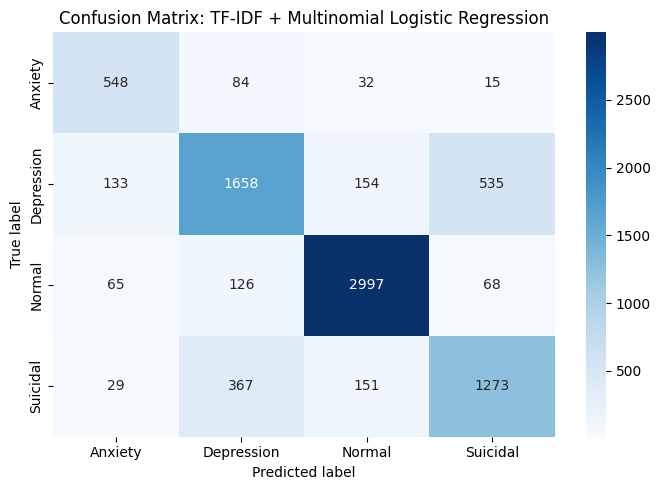

Suicidal one-vs-rest PR-AUC: 0.7166
Suicidal Average Precision:  0.7168


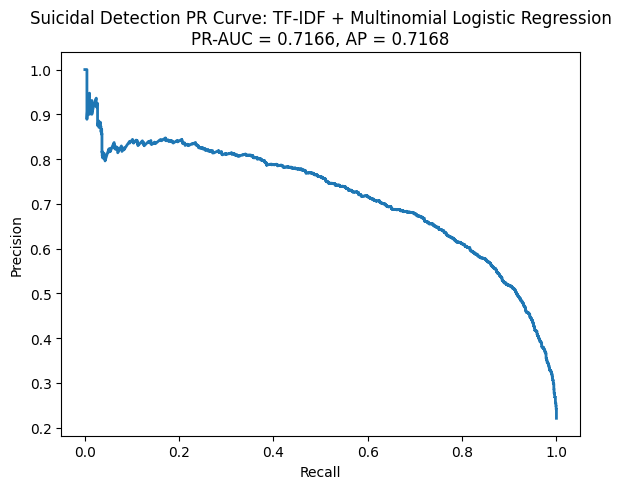


Cross-validation summary for TF-IDF + Multinomial Logistic Regression
cv_accuracy_mean: 0.7879
cv_accuracy_std: 0.0051
cv_macro_f1_mean: 0.7639
cv_macro_f1_std: 0.0053
cv_weighted_f1_mean: 0.7867
cv_weighted_f1_std: 0.0051


In [10]:
# Model 1 (Baseline): TF-IDF + Multinomial Logistic Regression
#
# Why this model?
# - Very strong classical baseline for text classification
# - Interpretable and fast
# - Often surprisingly competitive
#
# Why class_weight="balanced"?
# - The suicidal class is smaller than Normal / Depression
# - Balanced weights reduce bias toward the majority classes

tfidf_logreg = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),      # unigrams + bigrams
        min_df=3,                # ignore extremely rare terms
        max_df=0.95,             # ignore very common near-stopword terms
        sublinear_tf=True,       # log-scale term frequency
        strip_accents="unicode"
    )),

    # multi_class is just telling logistic regression how to handle more than 2 classes. 
    # but, scikit-learn is already choosing the multiclass behavior automatically,
    # so multiclass argument is unnecessary.
    ("clf", LogisticRegression(
        solver="saga",
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

res_tfidf_logreg = evaluate_classifier(
    model_name="TF-IDF + Multinomial Logistic Regression",
    model=tfidf_logreg,
    X_train=X_train_text,
    y_train=y_train,
    X_val=X_val_text,
    y_val=y_val,
    class_names=label_encoder.classes_,
    has_predict_proba=True
)

cv_tfidf_logreg = cross_validate_model(
    model_name="TF-IDF + Multinomial Logistic Regression",
    model=tfidf_logreg,
    X=X_text_all,
    y=y_all
)

## 2. TF-IDF + SVM

MODEL: TF-IDF + Calibrated Linear SVM
Accuracy:      0.7925
Macro F1:      0.7674
Weighted F1:   0.7894
Macro Prec.:   0.7859
Macro Recall:  0.7535

Classification report:
              precision    recall  f1-score   support

     Anxiety     0.8437    0.6996    0.7649       679
  Depression     0.7187    0.7242    0.7214      2480
      Normal     0.8807    0.9478    0.9130      3256
    Suicidal     0.7004    0.6423    0.6701      1820

    accuracy                         0.7925      8235
   macro avg     0.7859    0.7535    0.7674      8235
weighted avg     0.7890    0.7925    0.7894      8235



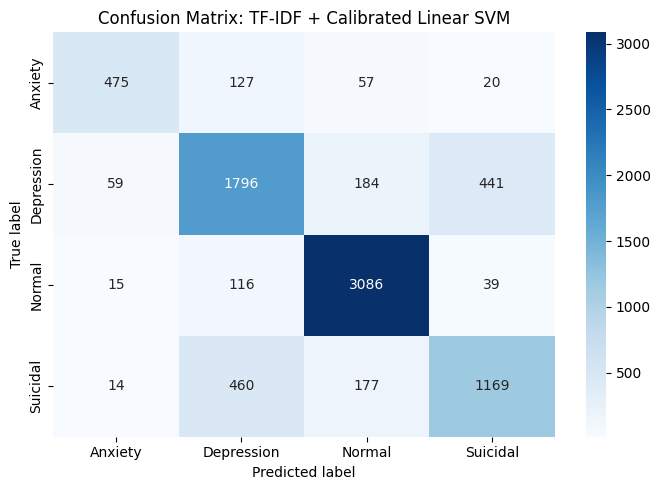

Suicidal one-vs-rest PR-AUC: 0.7232
Suicidal Average Precision:  0.7234


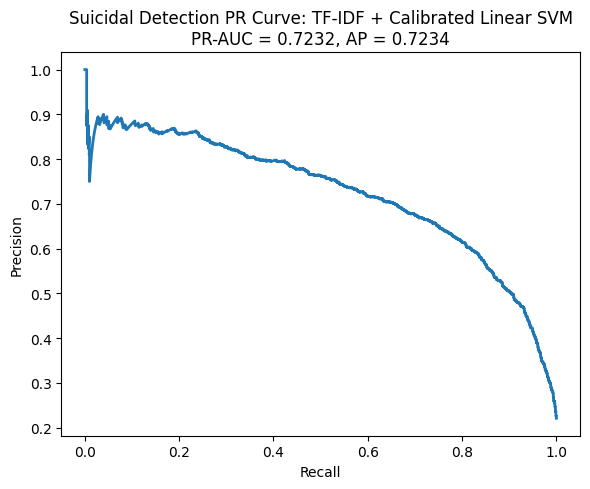


Cross-validation summary for TF-IDF + Calibrated Linear SVM
cv_accuracy_mean: 0.7931
cv_accuracy_std: 0.0031
cv_macro_f1_mean: 0.7672
cv_macro_f1_std: 0.0040
cv_weighted_f1_mean: 0.7900
cv_weighted_f1_std: 0.0031


In [ ]:
# Model 2 (Model Improvement): TF-IDF + Linear SVM
#
# Why Linear SVM here?
# - SVM often works better than logistic regression in high-dimensional spaces
# - it is strong for text classification
# - we already saw SVM outperform logistic regression in your TF-IDF models
#
# Why calibrated SVM?
# - LinearSVC does not output probabilities by default
# - calibration lets us estimate probabilities
# - that allows us to compute PR-AUC for the Suicidal class

base_linear_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.95,
        sublinear_tf=True,
        strip_accents="unicode"
    )),
    ("svm", LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

# Calibrate margins into probabilities using cross-validated calibration.
tfidf_svm = CalibratedClassifierCV(
    estimator=base_linear_svm,
    method="sigmoid",
    cv=3
)

res_tfidf_svm = evaluate_classifier(
    model_name="TF-IDF + Calibrated Linear SVM",
    model=tfidf_svm,
    X_train=X_train_text,
    y_train=y_train,
    X_val=X_val_text,
    y_val=y_val,
    class_names=label_encoder.classes_,
    has_predict_proba=True
)

cv_tfidf_svm = cross_validate_model(
    model_name="TF-IDF + Calibrated Linear SVM",
    model=tfidf_svm,
    X=X_text_all,
    y=y_all
)

### Why PR-AUC for Suicidal Class

We used PR-AUC for the suicidal class because overall accuracy alone is not sufficient for evaluating high-risk detection. We have noticed the presence of clear class imbalance where suicidal posts are less common than normal posts. Then a model can get decent accuracy just by predicting the larger classes well, even if it misses many suicidal posts.So accuracy can hide poor high-risk detection.

PR-AUC focuses on:
- Precision: when the model flags a post as suicidal, how often is it correct?
- Recall: how many truly suicidal posts did the model successfully find?

In a mental-health screening setting, the most important question is whether the model can reliably identify suicidal posts while balancing false alarms and missed cases. PR-AUC is useful because for early intervention which aligns with our research question of achieving detecting high-risk posts, we want a model that can identify suicidal posts well, not just do well overall.

### SVM outperforms LR
The TF-IDF + Linear SVM model performed slightly better than TF-IDF + Logistic Regression on all major metrics. Logistic Regression achieved an accuracy of 0.7864, macro-F1 of 0.7632, and suicidal PR-AUC of 0.7166, while the SVM achieved an accuracy of 0.7925, macro-F1 of 0.7674, and suicidal PR-AUC of 0.7232. Although the improvement was modest, it was consistent across all metrics, so the SVM was preferred. 

### Standard TF-IDF to Hybrid TF-IDF
Our initial baseline model used TF-IDF with word n-grams, which represents each post based on the frequency and importance of words in the dataset. This approach is widely used in classical text classification and performed well in our early experiments.

Word n-gram analyzes normal words such as:

- depressed
- want to die

In the cases where we have spelling mistake or informal text, a standard word-based TF-IDF model may fail to recognize the words because they are misspelled or written informally. To address this limitation, we extended the feature representation to a hybrid TF-IDF model that combines word n-grams and character n-grams.

Character n-grams help the model recognize misspelled or informal text, which is common in social media posts. For example:

- “I want to kill myself”

- “I wanna kil mes”

- “im depresed and tired”

These subword patterns remain similar even when words are misspelled or abbreviated. As a result, the hybrid representation allows the model to detect linguistic patterns that would otherwise be missed by word-only TF-IDF features. This improvement is particularly important for social media and mental health text analysis, where language is often informal and inconsistent.

## 3. Hybrid TF-IDF + SVM

MODEL: Hybrid TF-IDF (word+char) + Linear SVM
Accuracy:      0.7971
Macro F1:      0.7731
Weighted F1:   0.7943
Macro Prec.:   0.7889
Macro Recall:  0.7608

Classification report:
              precision    recall  f1-score   support

     Anxiety     0.8458    0.7187    0.7771       679
  Depression     0.7262    0.7262    0.7262      2480
      Normal     0.8900    0.9515    0.9197      3256
    Suicidal     0.6936    0.6467    0.6693      1820

    accuracy                         0.7971      8235
   macro avg     0.7889    0.7608    0.7731      8235
weighted avg     0.7936    0.7971    0.7943      8235



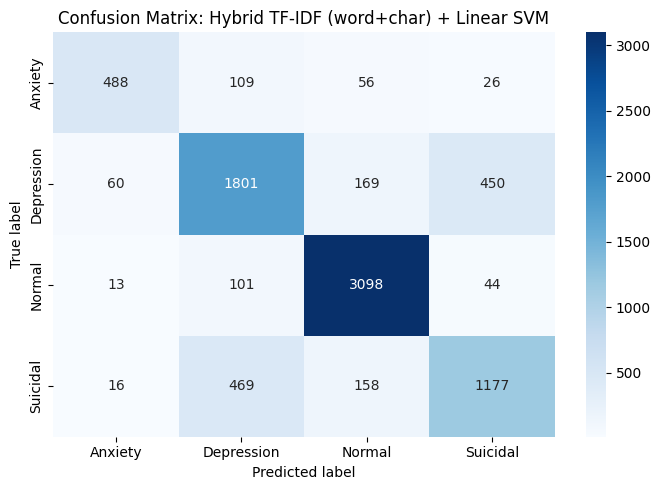

Suicidal one-vs-rest PR-AUC: 0.7225
Suicidal Average Precision:  0.7227


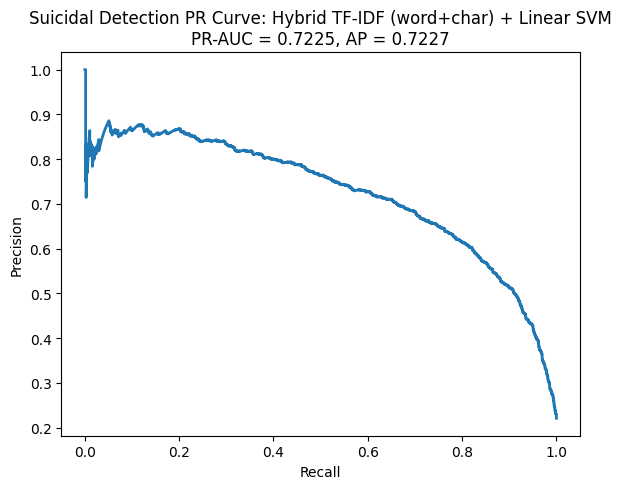


Cross-validation summary for Hybrid TF-IDF (word+char) + Linear SVM
cv_accuracy_mean: 0.7972
cv_accuracy_std: 0.0035
cv_macro_f1_mean: 0.7721
cv_macro_f1_std: 0.0036
cv_weighted_f1_mean: 0.7945
cv_weighted_f1_std: 0.0034


In [15]:
# Improved Model: Hybrid TF-IDF (word + character) + Linear SVM

word_tfidf = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1,2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True
)

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3,5),
    min_df=3,
    sublinear_tf=True
)

hybrid_tfidf = FeatureUnion([
    ("word", word_tfidf),
    ("char", char_tfidf)
])

base_hybrid_svm = Pipeline([
    ("features", hybrid_tfidf),
    ("svm", LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

hybrid_svm = CalibratedClassifierCV(
    estimator=base_hybrid_svm,
    method="sigmoid",
    cv=3
)

res_hybrid_svm = evaluate_classifier(
    model_name="Hybrid TF-IDF (word+char) + Linear SVM",
    model=hybrid_svm,
    X_train=X_train_text,
    y_train=y_train,
    X_val=X_val_text,
    y_val=y_val,
    class_names=label_encoder.classes_,
    has_predict_proba=True
)

cv_hybrid_svm = cross_validate_model(
    model_name="Hybrid TF-IDF (word+char) + Linear SVM",
    model=hybrid_svm,
    X=X_text_all,
    y=y_all
)

### Parameter Tuning (Grid Search)

Grid search was used to tune the SVM regularization parameter C, which controls the trade-off between fitting the training data and generalizing to unseen data.
- If C is too large, the model may overfit the training data.
- If C is too small, the model may underfit and fail to capture important patterns.

Grid search systematically evaluates multiple candidate values of C. In our experiment, we tested: C∈{0.1,  0.5,  1,  2,  5}. Testing a limited number of values keeps the tuning process computationally efficient, while still exploring a meaningful range of model behaviors.

We evaluated several candidate values using 3-fold cross-validation and selected the parameter that maximized macro-F1 score. The best value C=0.1 produced a cross-validated macro-F1 of 0.769 and slightly improved overall model performance.

We used macro-F1 score as the tuning metric because:
- target is multi-class
- dataset contains class imbalance
- macro-F1 evaluates performance equally across all classes

In [18]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter tuning for Hybrid TF-IDF + Linear SVM
#
# We tune the SVM regularization parameter C.
# This helps us find the best balance between:
# - fitting the training data
# - generalizing well to new data
#
# We use macro F1 as the tuning metric because:
# - this is a multiclass problem
# - classes are imbalanced
# - we want balanced performance across all classes

param_grid = {
    "estimator__svm__C": [0.1, 0.5, 1, 2, 5]
}

grid_hybrid_svm = GridSearchCV(
    estimator=hybrid_svm,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_hybrid_svm.fit(X_train_text, y_train)

print("Best parameters found:")
print(grid_hybrid_svm.best_params_)

print("\nBest cross-validated macro F1:")
print(grid_hybrid_svm.best_score_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best parameters found:
{'estimator__svm__C': 0.1}

Best cross-validated macro F1:
0.769229265546072


## 4. Tuned hybrid TF-IDF + SVM

MODEL: Tuned Hybrid TF-IDF (word+char) + Linear SVM
Accuracy:      0.7948
Macro F1:      0.7709
Weighted F1:   0.7916
Macro Prec.:   0.7828
Macro Recall:  0.7614

Classification report:
              precision    recall  f1-score   support

     Anxiety     0.8209    0.7290    0.7722       679
  Depression     0.7317    0.7093    0.7203      2480
      Normal     0.8801    0.9512    0.9142      3256
    Suicidal     0.6987    0.6560    0.6767      1820

    accuracy                         0.7948      8235
   macro avg     0.7828    0.7614    0.7709      8235
weighted avg     0.7904    0.7948    0.7916      8235



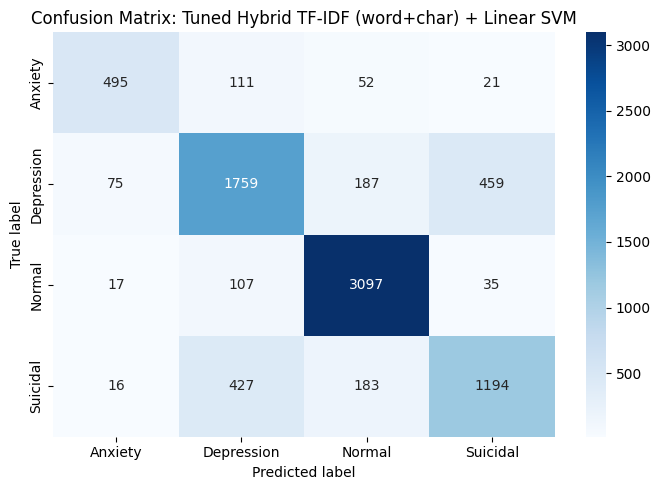

Suicidal one-vs-rest PR-AUC: 0.7252
Suicidal Average Precision:  0.7255


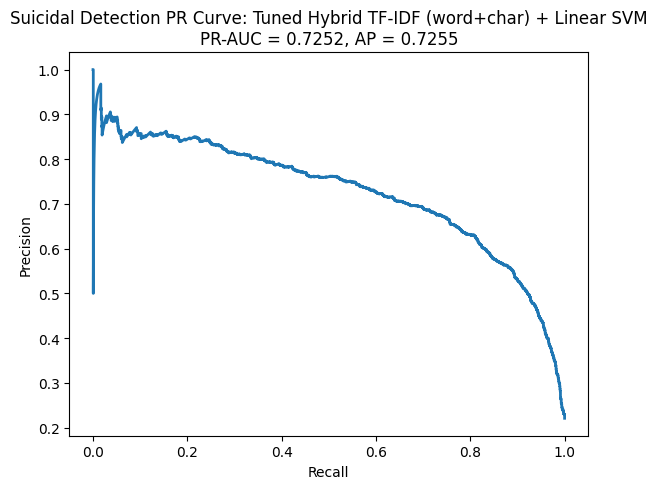

In [ ]:
# 4. Model: Tuned hybrid TF-IDF + SVM

best_hybrid_svm = grid_hybrid_svm.best_estimator_

res_best_hybrid_svm = evaluate_classifier(
    model_name="Tuned Hybrid TF-IDF (word+char) + Linear SVM",
    model=best_hybrid_svm,
    X_train=X_train_text,
    y_train=y_train,
    X_val=X_val_text,
    y_val=y_val,
    class_names=label_encoder.classes_,
    has_predict_proba=True
)

# Already used cross-validation on training data to find best regularization parameter above,
# so no need to evaluate again on CV.

### Best Model So Far
Using the best parameter, the **tuned hybrid TF-IDF + SVM** achieved:
- Accuracy: 0.7948
- Macro-F1: 0.7709
- Weighted-F1: 0.7916
- Suicidal PR-AUC: 0.7252

These results slightly improved upon the previous TF-IDF + SVM model, demonstrating that hyperparameter tuning helped find a better balance between model complexity and generalization.

# 5-2. Models (with Sentence Embedding)

In [ ]:
# Feature Representation: Sentence embeddings
# SentenceTransformer creates dense semantic vectors for each post.
# This often helps when different posts express similar meaning with different words.

embedding_model_name = "all-MiniLM-L6-v2"
embedding_model = SentenceTransformer(embedding_model_name)

# Encode the labeled train data and unlabeled test data.
# convert_to_numpy=True returns standard NumPy arrays.
X_embed_all = embedding_model.encode(
    train_df["clean_text_model"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

X_embed_test = embedding_model.encode(
    test_df["clean_text_model"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

# Split embeddings using the same train/validation indices as before.
X_embed_train = X_embed_all[idx_train]
X_embed_val = X_embed_all[idx_val]

print("Embedding train shape:", X_embed_train.shape)
print("Embedding val shape:", X_embed_val.shape)
print("Embedding test shape:", X_embed_test.shape)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3310.73it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 132/132 [00:27<00:00,  4.84it/s]

Embedding train shape: (32939, 384)
Embedding val shape: (8235, 384)
Embedding test shape: (8436, 384)


MODEL: Sentence Embeddings + Logistic Regression
Accuracy:      0.7683
Macro F1:      0.7364
Weighted F1:   0.7685
Macro Prec.:   0.7219
Macro Recall:  0.7677

Classification report:
              precision    recall  f1-score   support

     Anxiety     0.5769    0.8395    0.6839       679
  Depression     0.7412    0.6028    0.6649      2480
      Normal     0.9191    0.9039    0.9114      3256
    Suicidal     0.6504    0.7247    0.6856      1820

    accuracy                         0.7683      8235
   macro avg     0.7219    0.7677    0.7364      8235
weighted avg     0.7779    0.7683    0.7685      8235



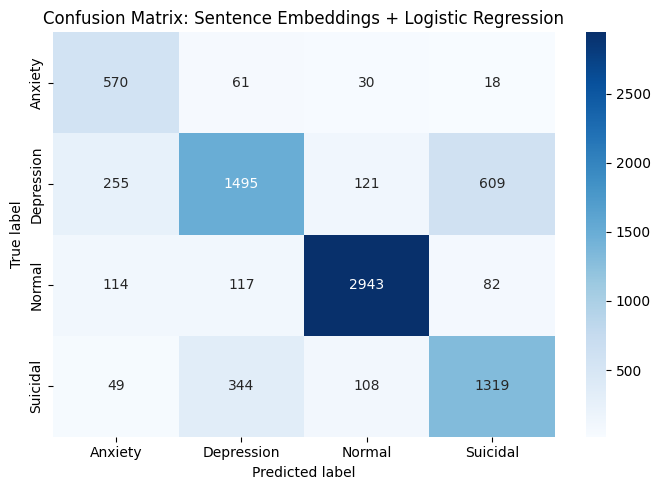

Suicidal one-vs-rest PR-AUC: 0.6957
Suicidal Average Precision:  0.6960


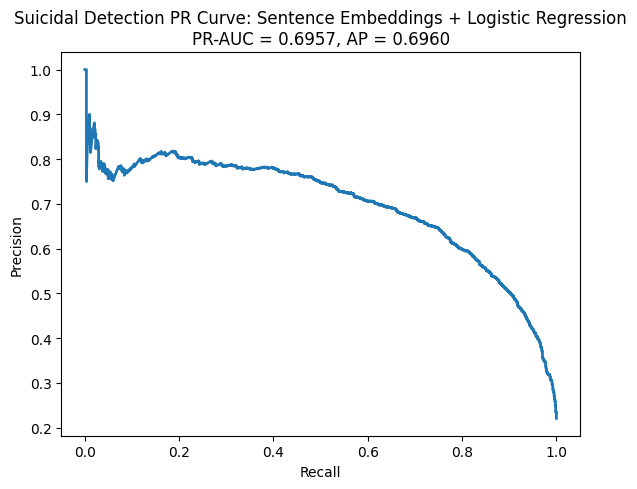


Cross-validation summary for Sentence Embeddings + Logistic Regression
cv_accuracy_mean: 0.7659
cv_accuracy_std: 0.0039
cv_macro_f1_mean: 0.7341
cv_macro_f1_std: 0.0044
cv_weighted_f1_mean: 0.7661
cv_weighted_f1_std: 0.0040


In [22]:
# Model 5 (Feature Improvement): Sentence Embeddings + Multinomial Logistic Regression

embed_logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        solver="saga",
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

res_embed_logreg = evaluate_classifier(
    model_name="Sentence Embeddings + Logistic Regression",
    model=embed_logreg,
    X_train=X_embed_train,
    y_train=y_train,
    X_val=X_embed_val,
    y_val=y_val,
    class_names=label_encoder.classes_,
    has_predict_proba=True
)

cv_embed_logreg = cross_validate_model(
    model_name="Sentence Embeddings + Logistic Regression",
    model=embed_logreg,
    X=X_embed_all,
    y=y_all
)

MODEL: Sentence Embeddings + Calibrated Linear SVM
Accuracy:      0.7806
Macro F1:      0.7483
Weighted F1:   0.7774
Macro Prec.:   0.7616
Macro Recall:  0.7380

Classification report:
              precision    recall  f1-score   support

     Anxiety     0.7749    0.6642    0.7153       679
  Depression     0.7092    0.6931    0.7011      2480
      Normal     0.8798    0.9441    0.9108      3256
    Suicidal     0.6824    0.6505    0.6661      1820

    accuracy                         0.7806      8235
   macro avg     0.7616    0.7380    0.7483      8235
weighted avg     0.7761    0.7806    0.7774      8235



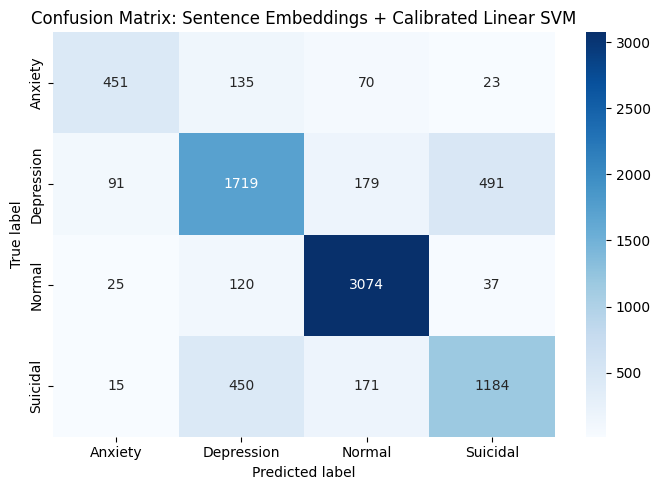

Suicidal one-vs-rest PR-AUC: 0.6974
Suicidal Average Precision:  0.6977


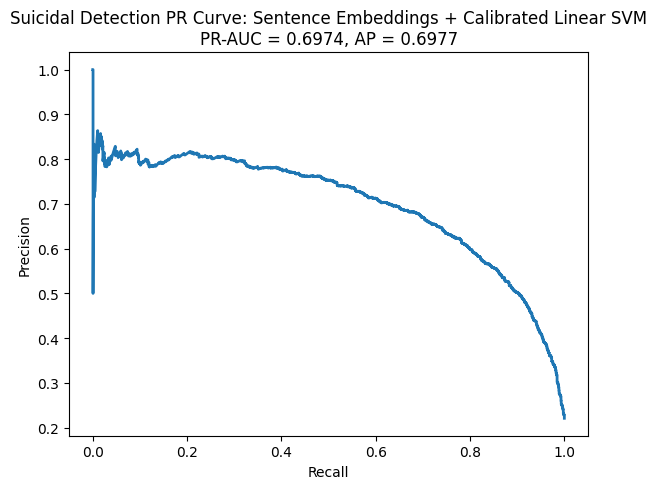


Cross-validation summary for Sentence Embeddings + Calibrated Linear SVM
cv_accuracy_mean: 0.7759
cv_accuracy_std: 0.0050
cv_macro_f1_mean: 0.7421
cv_macro_f1_std: 0.0067
cv_weighted_f1_mean: 0.7728
cv_weighted_f1_std: 0.0051


In [23]:
# Model 4 (Combined): Sentence Embeddings + Linear SVM

base_embed_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

embed_svm = CalibratedClassifierCV(
    estimator=base_embed_svm,
    method="sigmoid",
    cv=3
)

res_embed_svm = evaluate_classifier(
    model_name="Sentence Embeddings + Calibrated Linear SVM",
    model=embed_svm,
    X_train=X_embed_train,
    y_train=y_train,
    X_val=X_embed_val,
    y_val=y_val,
    class_names=label_encoder.classes_,
    has_predict_proba=True
)

cv_embed_svm = cross_validate_model(
    model_name="Sentence Embeddings + Calibrated Linear SVM",
    model=embed_svm,
    X=X_embed_all,
    y=y_all
)

In [ ]:
# Combine sentence embeddings with linguistic features
#
# Here we concatenate:
# - dense semantic embeddings
# - interpretable hand-crafted linguistic features
#
# This tests whether the engineered features add useful signal
# beyond the transformer sentence embeddings.

X_combined_all = np.hstack([X_embed_all, train_ling.values])
X_combined_test = np.hstack([X_embed_test, test_ling.values])

X_combined_train = X_combined_all[idx_train]
X_combined_val = X_combined_all[idx_val]

print("Combined train shape:", X_combined_train.shape)
print("Combined val shape:", X_combined_val.shape)

In [ ]:
# Model 6 (Advanced): Embeddings + Linguistic Features + Logistic Regression

combined_logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        multi_class="multinomial",
        solver="saga",
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

res_combined_logreg = evaluate_classifier(
    model_name="Embeddings + Linguistic Features + Logistic Regression",
    model=combined_logreg,
    X_train=X_combined_train,
    y_train=y_train,
    X_val=X_combined_val,
    y_val=y_val,
    class_names=label_encoder.classes_,
    has_predict_proba=True
)

cv_combined_logreg = cross_validate_model(
    model_name="Embeddings + Linguistic Features + Logistic Regression",
    model=combined_logreg,
    X=X_combined_all,
    y=y_all
)

In [ ]:
# Optional comparison models
#
# These are included because your outline mentioned them,
# but they should not be your main models.
#
# Why not?
# - Random Forest is not usually ideal for dense high-dimensional embeddings
# - kNN often suffers in high-dimensional spaces
#
# So treat these as optional benchmark comparisons.

RUN_OPTIONAL_MODELS = True

optional_results = []

if RUN_OPTIONAL_MODELS:
    # Random Forest
    rf_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    res_rf = evaluate_classifier(
        model_name="Sentence Embeddings + Random Forest (optional)",
        model=rf_model,
        X_train=X_embed_train,
        y_train=y_train,
        X_val=X_embed_val,
        y_val=y_val,
        class_names=label_encoder.classes_,
        has_predict_proba=True
    )
    optional_results.append(res_rf)

    # kNN
    knn_model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(
            n_neighbors=15,
            weights="distance",
            metric="cosine"
        ))
    ])

    res_knn = evaluate_classifier(
        model_name="Sentence Embeddings + kNN (optional)",
        model=knn_model,
        X_train=X_embed_train,
        y_train=y_train,
        X_val=X_embed_val,
        y_val=y_val,
        class_names=label_encoder.classes_,
        has_predict_proba=True
    )
    optional_results.append(res_knn)

In [ ]:
# Collect validation results into one table

all_results = [
    res_tfidf_logreg,
    res_tfidf_svm,
    res_embed_logreg,
    res_embed_svm,
    res_combined_logreg,
]

if RUN_OPTIONAL_MODELS:
    all_results.extend(optional_results)

results_df = pd.DataFrame(all_results)

# Sort mainly by macro F1, then suicidal PR-AUC if available
sort_cols = [c for c in ["macro_f1", "suicidal_pr_auc", "accuracy"] if c in results_df.columns]
results_df = results_df.sort_values(sort_cols, ascending=False).reset_index(drop=True)

display(results_df)

In [ ]:
# Cross-validation comparison table

cv_results_df = pd.DataFrame([
    cv_tfidf_logreg,
    cv_tfidf_svm,
    cv_embed_logreg,
    cv_embed_svm,
    cv_combined_logreg
])

cv_results_df = cv_results_df.sort_values(
    by=["cv_macro_f1_mean", "cv_accuracy_mean"],
    ascending=False
).reset_index(drop=True)

display(cv_results_df)

In [ ]:
# Plot model comparison for report figures

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="macro_f1", y="model")
plt.title("Validation Macro F1 by Model")
plt.xlabel("Macro F1")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

if "suicidal_pr_auc" in results_df.columns:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=results_df, x="suicidal_pr_auc", y="model")
    plt.title("Suicidal One-vs-Rest PR-AUC by Model")
    plt.xlabel("PR-AUC")
    plt.ylabel("Model")
    plt.tight_layout()
    plt.show()

In [ ]:
# Interpretability: top TF-IDF terms from logistic regression
#
# This gives interpretable evidence for your report.
# It shows which words/bigrams are strongly associated with each class
# according to the linear model.

# Refit the TF-IDF + logistic model on the full labeled data
tfidf_logreg.fit(X_text_all, y_all)

vectorizer = tfidf_logreg.named_steps["tfidf"]
logreg_clf = tfidf_logreg.named_steps["clf"]

feature_names = np.array(vectorizer.get_feature_names_out())

for class_index, class_name in enumerate(label_encoder.classes_):
    coef = logreg_clf.coef_[class_index]

    top_pos_idx = np.argsort(coef)[-15:][::-1]
    top_neg_idx = np.argsort(coef)[:15]

    print("=" * 80)
    print(f"CLASS: {class_name}")
    print("Top positive indicators:")
    for idx in top_pos_idx:
        print(f"{feature_names[idx]:<25} {coef[idx]:.4f}")

    print("\nTop negative indicators:")
    for idx in top_neg_idx:
        print(f"{feature_names[idx]:<25} {coef[idx]:.4f}")
    print()

In [ ]:
# Choose the best model for final training
#
# Recommendation:
# - If a model wins on macro F1 and also has strong suicidal PR-AUC,
#   prefer that one.
# - In many text tasks, the best practical model is often either:
#   * TF-IDF + calibrated linear SVM
#   * embeddings + logistic regression
#   * embeddings + features + logistic regression
#
# Edit BEST_MODEL_NAME if your results suggest a different winner.

BEST_MODEL_NAME = results_df.loc[0, "model"]
print("Best validation model selected:", BEST_MODEL_NAME)

In [ ]:
# ============================================================
# Retrain the selected best non-transformer model on full labeled data
# and generate predictions for the unlabeled test set
# ============================================================

best_model = None
best_input_train = None
best_input_test = None

if BEST_MODEL_NAME == "TF-IDF + Multinomial Logistic Regression":
    best_model = tfidf_logreg
    best_input_train = X_text_all
    best_input_test = test_df["clean_text_model"]

elif BEST_MODEL_NAME == "TF-IDF + Calibrated Linear SVM":
    best_model = tfidf_svm
    best_input_train = X_text_all
    best_input_test = test_df["clean_text_model"]

elif BEST_MODEL_NAME == "Sentence Embeddings + Logistic Regression":
    best_model = embed_logreg
    best_input_train = X_embed_all
    best_input_test = X_embed_test

elif BEST_MODEL_NAME == "Sentence Embeddings + Calibrated Linear SVM":
    best_model = embed_svm
    best_input_train = X_embed_all
    best_input_test = X_embed_test

elif BEST_MODEL_NAME == "Embeddings + Linguistic Features + Logistic Regression":
    best_model = combined_logreg
    best_input_train = X_combined_all
    best_input_test = X_combined_test

elif BEST_MODEL_NAME == "Sentence Embeddings + Random Forest (optional)":
    best_model = rf_model
    best_input_train = X_embed_all
    best_input_test = X_embed_test

elif BEST_MODEL_NAME == "Sentence Embeddings + kNN (optional)":
    best_model = knn_model
    best_input_train = X_embed_all
    best_input_test = X_embed_test

else:
    raise ValueError("BEST_MODEL_NAME does not match a known model.")

# Fit on all labeled training data
best_model.fit(best_input_train, y_all)

# Predict final unlabeled test labels
test_pred_int = best_model.predict(best_input_test)
test_pred_labels = label_encoder.inverse_transform(test_pred_int)

submission_df = pd.DataFrame({
    "id": test_df["id"],
    "status": test_pred_labels
})

display(submission_df.head())

submission_path = "submission_best_non_transformer.csv"
submission_df.to_csv(submission_path, index=False)

print(f"Saved final prediction file to: {submission_path}")

In [ ]:
# ============================================================
# Save summary tables for your report
# ============================================================

results_df.to_csv("validation_model_comparison.csv", index=False)
cv_results_df.to_csv("cross_validation_model_comparison.csv", index=False)

print("Saved:")
print("- validation_model_comparison.csv")
print("- cross_validation_model_comparison.csv")

In [ ]:
# ============================================================
# OPTIONAL MORE ADVANCED MODEL: DistilBERT fine-tuning
# ============================================================
#
# This section is optional because it requires more compute time.
# It is included because your project outline mentions BERT-like models.
#
# DistilBERT is lighter than BERT and often a good practical compromise.
#
# IMPORTANT:
# - Run this only if your machine can handle transformers.
# - If you get memory issues, reduce MAX_LENGTH and BATCH_SIZE.
# - Use this model as an advanced comparison, not the only result.

RUN_BERT = False

In [ ]:
# Transformer Imports
if RUN_BERT:
    from datasets import Dataset
    import evaluate

    from transformers import (
        AutoTokenizer,
        AutoModelForSequenceClassification,
        TrainingArguments,
        Trainer,
        DataCollatorWithPadding
    )

In [ ]:
# Prepare datasets for DistilBERT
if RUN_BERT:
    # Create a new labeled train/validation split specifically for the transformer.
    bert_train_df, bert_val_df = train_test_split(
        train_df[["text", "status"]].copy(),
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=train_df["status"]
    )

    bert_train_df = bert_train_df.reset_index(drop=True)
    bert_val_df = bert_val_df.reset_index(drop=True)

    # Encode labels numerically using the same classes as before.
    bert_train_df["label"] = label_encoder.transform(bert_train_df["status"])
    bert_val_df["label"] = label_encoder.transform(bert_val_df["status"])

    # Convert pandas DataFrames into Hugging Face Dataset objects.
    ds_train = Dataset.from_pandas(bert_train_df[["text", "label"]], preserve_index=False)
    ds_val = Dataset.from_pandas(bert_val_df[["text", "label"]], preserve_index=False)

    model_checkpoint = "distilbert-base-uncased"
    tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

In [ ]:
# Tokenization

if RUN_BERT:
    MAX_LENGTH = 256

    def tokenize_batch(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            max_length=MAX_LENGTH
        )

    tokenized_train = ds_train.map(tokenize_batch, batched=True)
    tokenized_val = ds_val.map(tokenize_batch, batched=True)

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
# Metrics for Transformer
if RUN_BERT:
    accuracy_metric = evaluate.load("accuracy")
    f1_metric = evaluate.load("f1")
    precision_metric = evaluate.load("precision")
    recall_metric = evaluate.load("recall")

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=1)

        return {
            "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
            "macro_f1": f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"],
            "weighted_f1": f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"],
            "macro_precision": precision_metric.compute(predictions=preds, references=labels, average="macro")["precision"],
            "macro_recall": recall_metric.compute(predictions=preds, references=labels, average="macro")["recall"],
        }

In [ ]:
# Fine-tune DistilBERT
if RUN_BERT:
    id2label = {i: label for i, label in enumerate(label_encoder.classes_)}
    label2id = {label: i for i, label in enumerate(label_encoder.classes_)}

    bert_model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint,
        num_labels=len(label_encoder.classes_),
        id2label=id2label,
        label2id=label2id
    )

    training_args = TrainingArguments(
        output_dir="./distilbert_mental_health",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=2,
        weight_decay=0.01,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        report_to="none"
    )

    trainer = Trainer(
        model=bert_model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

    trainer.train()

In [ ]:
# Evaluate DistilBERT and compute PR-AUC
if RUN_BERT:
    # Get validation predictions
    bert_pred_output = trainer.predict(tokenized_val)
    bert_logits = bert_pred_output.predictions
    bert_y_true = bert_pred_output.label_ids
    bert_y_pred = np.argmax(bert_logits, axis=1)

    # Softmax probabilities
    exp_logits = np.exp(bert_logits - bert_logits.max(axis=1, keepdims=True))
    bert_probs = exp_logits / exp_logits.sum(axis=1, keepdims=True)

    print("DistilBERT validation report:")
    print(classification_report(
        bert_y_true,
        bert_y_pred,
        target_names=label_encoder.classes_,
        digits=4,
        zero_division=0
    ))

    plot_confusion(
        y_true=bert_y_true,
        y_pred=bert_y_pred,
        class_names=label_encoder.classes_,
        title="Confusion Matrix: DistilBERT"
    )

    bert_pr = suicidal_pr_auc_from_probs(
        y_true=bert_y_true,
        y_prob=bert_probs,
        class_names=label_encoder.classes_
    )

    print(f"DistilBERT suicidal PR-AUC: {bert_pr['pr_auc']:.4f}")
    print(f"DistilBERT suicidal AP:     {bert_pr['average_precision']:.4f}")

    plot_pr_curve(bert_pr, title="Suicidal Detection PR Curve: DistilBERT")

    distilbert_results = {
        "model": "DistilBERT fine-tuned",
        "accuracy": accuracy_score(bert_y_true, bert_y_pred),
        "macro_f1": f1_score(bert_y_true, bert_y_pred, average="macro"),
        "weighted_f1": f1_score(bert_y_true, bert_y_pred, average="weighted"),
        "macro_precision": precision_score(bert_y_true, bert_y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(bert_y_true, bert_y_pred, average="macro", zero_division=0),
        "suicidal_pr_auc": bert_pr["pr_auc"],
        "suicidal_average_precision": bert_pr["average_precision"]
    }

    print("\nDistilBERT summary:")
    print(distilbert_results)

In [ ]:
# Optional final transformer predictions for test set
if RUN_BERT:
    # Retrain on the full labeled data for final test prediction
    full_transformer_df = train_df[["text", "status"]].copy()
    full_transformer_df["label"] = label_encoder.transform(full_transformer_df["status"])

    ds_full = Dataset.from_pandas(full_transformer_df[["text", "label"]], preserve_index=False)
    ds_test = Dataset.from_pandas(test_df[["text"]].copy(), preserve_index=False)

    tokenized_full = ds_full.map(tokenize_batch, batched=True)
    tokenized_test = ds_test.map(tokenize_batch, batched=True)

    final_bert_model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint,
        num_labels=len(label_encoder.classes_),
        id2label=id2label,
        label2id=label2id
    )

    final_training_args = TrainingArguments(
        output_dir="./distilbert_full_train",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=2,
        weight_decay=0.01,
        save_strategy="no",
        logging_strategy="epoch",
        report_to="none"
    )

    final_trainer = Trainer(
        model=final_bert_model,
        args=final_training_args,
        train_dataset=tokenized_full,
        tokenizer=tokenizer,
        data_collator=data_collator
    )

    final_trainer.train()

    test_outputs = final_trainer.predict(tokenized_test)
    test_logits = test_outputs.predictions
    test_pred_int = np.argmax(test_logits, axis=1)
    test_pred_labels = label_encoder.inverse_transform(test_pred_int)

    bert_submission_df = pd.DataFrame({
        "id": test_df["id"],
        "status": test_pred_labels
    })

    bert_submission_df.to_csv("submission_distilbert.csv", index=False)
    display(bert_submission_df.head())
    print("Saved: submission_distilbert.csv")

In [ ]:
# Final notebook summary text
#
# This prints a concise summary you can adapt into the report.

print("Modeling summary:")
print("- We used the provided labeled training data for model development and internal validation.")
print("- We reserved the provided unlabeled test data for final prediction output only.")
print("- We compared classical TF-IDF baselines, sentence-embedding models, and an optional transformer.")
print("- We corrected the preprocessing pipeline to preserve emotional punctuation (! and ?), consistent with the project rationale.")
print("- We handled class imbalance using class_weight='balanced'.")
print("- We evaluated both general multiclass performance and suicidal one-vs-rest intervention usefulness using PR-AUC.")
print("- We used stratified cross-validation to reduce dependence on a single validation split.")
print("- We exported final predictions for the unlabeled test set.")

# Although Random Forest and kNN were included in the original plan as optional models, they were treated as 
# secondary baselines because prior work and our own experiments suggest that linear models and transformer-based 
# approaches are generally better suited to high-dimensional sparse text or dense semantic embeddings. 
# We also revised the preprocessing pipeline to preserve emotionally meaningful punctuation such as 
# exclamation marks and question marks, since removing them would contradict the project’s theoretical motivation. 
# Finally, because the practical goal includes flagging high-risk content for possible intervention, we supplemented 
# standard multiclass metrics with suicidal-class precision-recall evaluation, which is more informative under 
# class imbalance. Reviews of suicide and mental-health text classification commonly note the importance of 
# imbalance-aware evaluation and the strong performance of transformer-based models, while also recognizing that 
# simpler linear baselines remain important benchmarks.